### Background of calculation
Dispersion relation on 1D discrete grid:
\begin{align}
c_t &= \frac{\hbar^2}{2 \, m_e \, dx}\\
E_{e} &= 2 \, c_t \, (1-\cos(k_e \, dx))
\end{align}
The connection between the wavenumber of the electron ($\lambda_e$) and the wavelength reads:
\begin{align}
k_e &= \frac{2 \pi}{\lambda_e} 
\end{align}
Lets note the number of the points under one $\lambda_e$ with $n_l$ thus $\lambda_e=n_l*dx$.
\begin{align}
E_{e} &= 2 \, c_t \, \left(1-\cos\left(\frac{2 \pi}{n_l}\right)\right)\\
\left(\frac{2 \pi}{ \arccos \left( 1 - \frac{E_{e}}{2 \, c_t} \right) }\right) &= n_l
\end{align}
the power series of the $\arccos(x)$ reads:
\begin{align}
 \arccos(x) \approx \frac{\pi}{2} - x
\end{align}
thus
\begin{align}
n_l \approx \frac{2 \pi}{ \frac{\pi}{2} - 1 + \frac{E_{e}}{2 \, c_t} }
\end{align}

In [1]:
# Fixed parameters for the optimization
dx=0.025 # Grid step size in the unit system
emax=6 # Maximum electron energy in eV
npx = 22*1024
effective_mass = 1.1

# Desired parameters
desired_points_in_lamda = 20
desired_width = 2000

In [2]:
from atomic_units.optimizer import optimize_atomic_units

# Perform optimization
result = optimize_atomic_units(dx, npx, emax, desired_points_in_lamda, desired_width)
print("Optimized parameters:", result['optimized_parameters'])
print("Objective function value:", result['objective_value'])

Optimized parameters: 2.9, 5.7, 1.0, 10.0
Objective function value: 0.2043
Optimized parameters: [10.          4.30002183  1.         39.50352551]
Objective function value: 0.20229104333842657


In [14]:
import atomic_units as au

hb=10.0#1.0
m0=4.3#8.8
kappa0=1.0#2.3 # 4*pi*epsilon0
e0=40.0#3.4
dx=0.025

unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=kappa0)

#print(unit_sys)
print(unit_sys.fine_structure_constant)
print(unit_sys.energy_unit.to('eV'))
print(unit_sys.length_unit.to('nm'))
print(dx*unit_sys.length_unit.to('nm'))
print(1/unit_sys.fine_structure_constant)

0.007297352569307099 dimensionless
0.00024719645935672674 electron_volt
3.640739211019365 nanometer
0.09101848027548413 nanometer
137.0359990835625 dimensionless


# Set unified grid

In [15]:
import numpy as np

uxgrid_num = 8*1024
uxgrid_dx = dx
uxgrid_width=uxgrid_num*uxgrid_dx
uxgrid = np.arange( -uxgrid_width/2 , uxgrid_width/2, uxgrid_dx)

print(type(uxgrid)) 
print(uxgrid_dx)
print(uxgrid_width)
print(uxgrid_width*unit_sys.length_unit.to('nm'))
print(npx*uxgrid_dx*unit_sys.length_unit.to('nm'))

<class 'numpy.ndarray'>
0.025
204.8
745.623390416766 nanometer
2050.4643236461065 nanometer


In [16]:
import quantum_toolkit as quat
# Create a dispersion object with the specified grid spacing
#dispersion=quat.Dispersion(uxgrid_dx, hbar = unit_sys.hb,mass = unit_sys.me)

qdisp=quat.QuadraticDispersion(hbar = unit_sys.hb,mass = unit_sys.me)
cdisp=quat.CosineDispersion(uxgrid_dx,hbar = unit_sys.hb,mass = unit_sys.me)

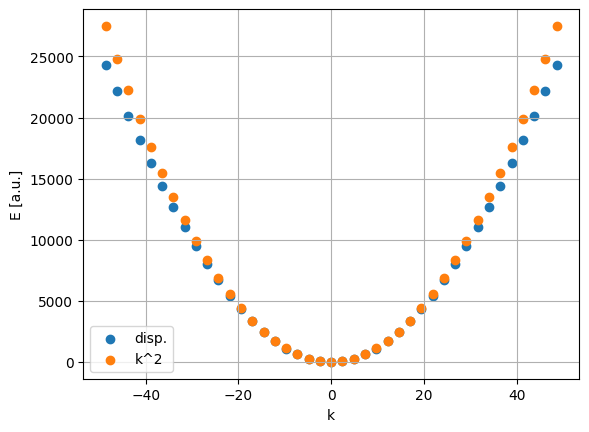

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  _data = np.array(data, dtype=dtype, copy=copy,


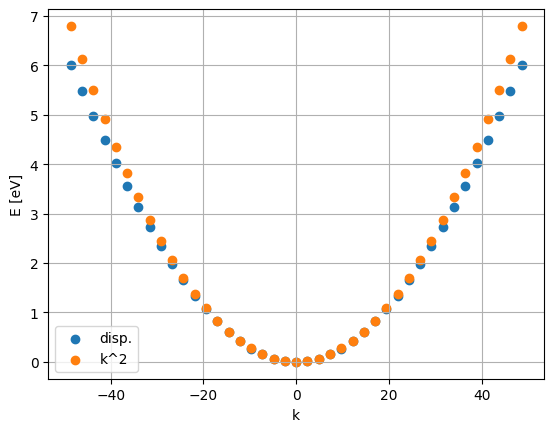

In [17]:
import matplotlib.pyplot as plt

emax_in_unit_sys = emax*unit_sys.convert_energy_from("eV")
k_max = cdisp.wavenumber(emax_in_unit_sys)

ukgrid_max = k_max
ukgrid_min = -k_max
ukgrid_num = 41

ukgrid, ukgrid_dx = np.linspace(ukgrid_min, ukgrid_max,\
                               ukgrid_num,retstep=True)

# print(ukgrid_dx)
# print(ukgrid_num)
# print(ukgrid)

evals_from_disp = cdisp.energy(ukgrid)
evals_from_quad = qdisp.energy(ukgrid)#((unit_sys.hb**2)/(2*unit_sys.me))*ukgrid**2

plt.scatter(ukgrid,evals_from_disp,label="disp.")
plt.scatter(ukgrid,evals_from_quad,label="k^2")
plt.xlabel("k")
plt.ylabel("E [a.u.]")
plt.legend()
plt.grid()
plt.show()

plt.scatter(ukgrid,evals_from_disp*unit_sys.energy_unit.to('eV'),label="disp.")
plt.scatter(ukgrid,evals_from_quad*unit_sys.energy_unit.to('eV'),label="k^2")
plt.xlabel("k")
plt.ylabel("E [eV]")
plt.legend()
plt.grid()
plt.show()

In [18]:
gold_fermi_energy_in_si = 5.53*unit_sys.ureg('eV')
gold_fermi_velocity_in_si = 1.4e6*unit_sys.ureg('m/s')
gold_effective_mass_in_si = 1.1*unit_sys.ureg('m_e').to('kg')
gold_fermi_wavenumber_in_si = (gold_fermi_velocity_in_si*gold_effective_mass_in_si/unit_sys.ureg("hbar")).to('1/m')

gold_fermi_energy_in_unit_sys = (gold_fermi_energy_in_si*unit_sys.convert_energy_from('eV')).magnitude
gold_fermi_velocity_in_unit_sys = (gold_fermi_velocity_in_si.to('m/s')/unit_sys.velocity_unit.to('m/s')).magnitude
gold_effective_mass_in_unit_sys = (gold_effective_mass_in_si/unit_sys.mass_unit.to('kg')).magnitude
gold_fermi_wavenumber_in_unit_sys = (gold_fermi_wavenumber_in_si.to('1/m')/unit_sys.wavenumber_unit.to('1/m')).magnitude

print("Gold Fermi energy:", gold_fermi_energy_in_si,"->", gold_effective_mass_in_unit_sys)
print("Gold Fermi velocity:", gold_fermi_velocity_in_si,"->", gold_fermi_velocity_in_unit_sys)
print("Gold effective mass:", gold_effective_mass_in_si,"->", gold_effective_mass_in_unit_sys)
print("Gold Fermi wavenumber:", gold_fermi_wavenumber_in_si,"->", gold_fermi_wavenumber_in_unit_sys)

Gold Fermi energy: 5.53 electron_volt -> 4.73
Gold Fermi velocity: 1400000.0 meter / second -> 102.39104745829856
Gold effective mass: 1.0020322071650002e-30 kilogram -> 4.73
Gold Fermi wavenumber: 13302508815.020325 / meter -> 48.43096544777525


In [19]:
effective_masses = [1.0, 0.5, 0.25, 0.1, 0.05, 0.031, 0.01]
fermi_energies_at_kf = []
dispersions = []
for effective_mass in effective_masses:
    effective_mass_in_si = effective_mass*unit_sys.ureg('m_e').to('kg')
    effective_mass_in_unit_sys = (effective_mass_in_si/unit_sys.mass_unit.to('kg')).magnitude
    dispersion=quat.CosineDispersion(uxgrid_dx, hbar = unit_sys.hb,\
                                mass = effective_mass_in_unit_sys)
    dispersions.append(dispersion)
    
    ef_at_kf=dispersion.energy(gold_fermi_wavenumber_in_unit_sys)
    fermi_energies_at_kf.append(ef_at_kf)
    print("Effective mass:", effective_mass, effective_mass_in_si, "->", effective_mass_in_unit_sys)
    print("Fermi energy at kf:", ef_at_kf, "->", ef_at_kf*unit_sys.energy_unit.to('eV'))

Effective mass: 1.0 9.1093837015e-31 kilogram -> 4.3
Fermi energy at kf: 24100.651114385408 -> 5.957595623667824 electron_volt
Effective mass: 0.5 4.55469185075e-31 kilogram -> 2.15
Fermi energy at kf: 48201.302228770815 -> 11.915191247335647 electron_volt
Effective mass: 0.25 2.277345925375e-31 kilogram -> 1.075
Fermi energy at kf: 96402.60445754163 -> 23.830382494671294 electron_volt
Effective mass: 0.1 9.109383701500001e-32 kilogram -> 0.43000000000000005
Fermi energy at kf: 241006.511143854 -> 59.575956236678216 electron_volt
Effective mass: 0.05 4.5546918507500006e-32 kilogram -> 0.21500000000000002
Fermi energy at kf: 482013.022287708 -> 119.15191247335643 electron_volt
Effective mass: 0.031 2.8239089474650004e-32 kilogram -> 0.1333
Fermi energy at kf: 777440.3585285615 -> 192.18050398928463 electron_volt
Effective mass: 0.01 9.1093837015e-33 kilogram -> 0.043
Fermi energy at kf: 2410065.1114385407 -> 595.7595623667823 electron_volt


/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


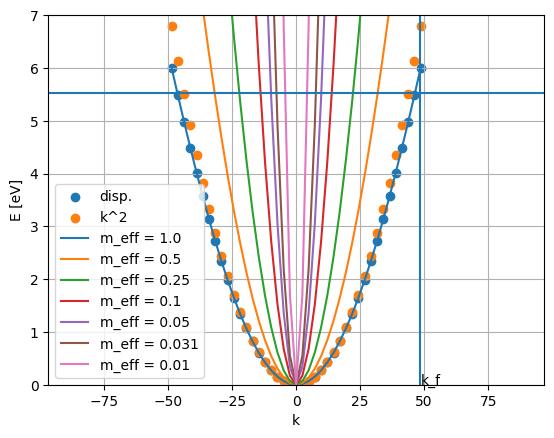

In [20]:
plt.scatter(ukgrid,evals_from_disp*unit_sys.energy_unit.to('eV'),label="disp.")
plt.scatter(ukgrid,evals_from_quad*unit_sys.energy_unit.to('eV'),label="k^2")
for dispersion, effective_mass in zip(dispersions, effective_masses):
    evals_from_disp = dispersion.energy(ukgrid)
    plt.plot(ukgrid,evals_from_disp*unit_sys.energy_unit.to('eV'),label="m_eff = "+str(effective_mass))

plt.axvline(gold_fermi_wavenumber_in_unit_sys)
plt.axhline(gold_fermi_energy_in_si.magnitude)
plt.text(gold_fermi_wavenumber_in_unit_sys+0.1,0,'k_f')
plt.xlabel("k")
plt.ylabel("E [eV]")
plt.xlim(-2*gold_fermi_wavenumber_in_unit_sys,2*gold_fermi_wavenumber_in_unit_sys)
plt.ylim(0, 7)
plt.legend()
plt.grid()
plt.show()

In [21]:
kf_of_gold_in_si = 1.21e10*unit_sys.ureg('1/m')
print(unit_sys.wavenumber_unit.to('1/m'))
kf_of_gold_in_unit_sys = (kf_of_gold_in_si.to('1/m')/unit_sys.wavenumber_unit.to('1/m')).magnitude
print(kf_of_gold_in_unit_sys)

274669494.8578894 / meter
44.05294445333433


In [22]:
print(k_max)
lambda_min = 2*np.pi/k_max
print(lambda_min)
num_of_points_in_lambda = lambda_min/uxgrid_dx
print(num_of_points_in_lambda)

48.627823059082246
0.12920967692807445
5.168387077122977


In [23]:
from quantum_toolkit import quantum_transport_toolkit as trat
import quantum_toolkit as quat
from quantum_toolkit import potentials as pots

ein=emax_in_unit_sys
kin=cdisp.wavenumber(ein)

zeropot=pots.ZeroPotential(uxgrid)

ham_static = quat.HamiltonOperator(uxgrid,hbar=unit_sys.hb,\
                                   me=unit_sys.me,\
                                   charge=unit_sys.e0,\
                                   scalarpot=zeropot,\
                                   vectorpot=zeropot )

qppk, qpmk = trat.quasiparticles_at_given_energy(ein, kin, ham_static)

2.8663258743688635e-05 2.8750382060298425e-19


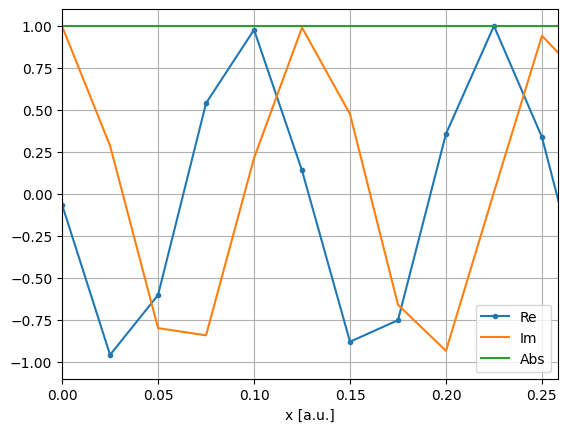

In [24]:
plt.plot(uxgrid,np.real(qppk["state"]["value"]),'.-',label="Re")
plt.plot(uxgrid,np.imag(qppk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qppk["state"]["value"]),label="Abs")
plt.xlabel("x [a.u.]")
plt.xlim([0, 2*lambda_min])
plt.legend()
plt.grid()
plt.show()